<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Assignment_Day_13_Adnan_Data_Manipulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jawablah poin-poin assignment berikut
#### perhatikan dengan baik apa yang diminta pada soal

# 1. Anda bekerja sebagai seorang data scientist, atasan anda mengirimkan anda data kepada anda dan meminta untuk memberikan analisa dengan menggunakan semua metode pada data manipulation berikut :
- a. Filtering
- b. Sorting
- c. Grouping / Aggregasi
- d. Join / Merging
- e. Pivot
- f. Crosstab
- g. Appending
- h. Mengeksplor terkait dengan operasi pada Datetime (week, day, dan sebagainya)
### Notes : Sebelum menjawab permintaan diatas, pertama-tama awali dengan mengajukan pertanyaan analisa terlebih dahulu dan tulis insight dari yang anda dapat, **pertanyaan analisa dilakukan pada semua metode data manipulation diatas**

## Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', None)

# Load datasets
df = pd.read_csv('supermarket_sales.csv')
df_branch = pd.read_csv('branch_info.csv')
df_product = pd.read_csv('product_info.csv')

# Konversi kolom Date dan Time
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

print('Shape supermarket_sales:', df.shape)
print('Shape branch_info:', df_branch.shape)
print('Shape product_info:', df_product.shape)
df.head()

Shape supermarket_sales: (1000, 17)
Shape branch_info: (3, 4)
Shape product_info: (3, 4)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


## Pertanyaan Analisa

Sebelum melakukan manipulasi data, berikut pertanyaan analisa yang diajukan:

**a. Filtering:**
- Transaksi mana saja yang dilakukan oleh Member dengan total pembelian di atas rata-rata?

**b. Sorting:**
- Bagaimana urutan transaksi berdasarkan total pembelian tertinggi ke terendah?

**c. Grouping / Aggregasi:**
- Berapa rata-rata total penjualan per cabang (Branch) dan per lini produk (Product line)?

**d. Join / Merging:**
- Informasi apa yang bisa kita dapatkan jika kita gabungkan data penjualan dengan data cabang dan data produk?

**e. Pivot:**
- Bagaimana perbandingan rata-rata total penjualan per cabang dan tipe pelanggan?

**f. Crosstab:**
- Bagaimana distribusi frekuensi transaksi per cabang dan metode pembayaran?

**g. Appending:**
- Bagaimana cara menggabungkan data dari dua cabang berbeda menjadi satu dataset?

**h. Datetime:**
- Apakah ada pola penjualan berdasarkan hari dalam seminggu atau jam tertentu?

## a. Filtering
**Pertanyaan:** Transaksi mana saja yang dilakukan oleh Member dengan total pembelian di atas rata-rata?

In [2]:
# Hitung rata-rata total
avg_total = df['Total'].mean()
print(f'Rata-rata Total: {avg_total:.2f}')

# Filter: Member dengan total di atas rata-rata
df_filtered = df[(df['Customer type'] == 'Member') & (df['Total'] > avg_total)]
print(f'Jumlah transaksi Member dengan Total > rata-rata: {len(df_filtered)}')
df_filtered[['Invoice ID', 'Branch', 'Customer type', 'Product line', 'Total']].head(10)

Rata-rata Total: 322.97
Jumlah transaksi Member dengan Total > rata-rata: 204


,Invoice ID,Branch,Customer type,Product line,Total
0,750-67-8428,A,Member,Health and beauty,548.9715
3,123-19-1176,A,Member,Health and beauty,489.0480
6,355-53-5943,A,Member,Electronic accessories,433.6920
15,299-46-1805,B,Member,Sports and travel,590.4360
16,656-95-9349,A,Member,Health and beauty,506.6355
20,300-71-4605,C,Member,Electronic accessories,451.7100
25,227-03-5010,A,Member,Home and lifestyle,441.7560
31,149-71-6266,B,Member,Sports and travel,737.7615
34,183-56-6882,C,Member,Food and beverages,417.5640
36,129-29-8530,A,Member,Sports and travel,328.7550


**Insight Filtering:**
Dengan memfilter transaksi Member yang memiliki total di atas rata-rata, kita dapat mengidentifikasi pelanggan loyal (Member) yang juga merupakan pembeli bernilai tinggi. Segmen ini adalah target potensial untuk program loyalitas atau promosi eksklusif.

## b. Sorting
**Pertanyaan:** Bagaimana urutan transaksi berdasarkan total pembelian tertinggi ke terendah?

In [3]:
# Sorting berdasarkan Total descending
df_sorted = df.sort_values(by='Total', ascending=False)
print('Top 10 transaksi dengan total tertinggi:')
df_sorted[['Invoice ID', 'Branch', 'City', 'Product line', 'Quantity', 'Total']].head(10)

Top 10 transaksi dengan total tertinggi:


,Invoice ID,Branch,City,Product line,Quantity,Total
350,860-79-0874,C,Naypyitaw,Fashion accessories,10,1042.650
167,687-47-8271,A,Yangon,Fashion accessories,10,1039.290
557,283-26-5248,C,Naypyitaw,Food and beverages,10,1034.460
699,751-41-9720,C,Naypyitaw,Home and lifestyle,10,1023.750
996,303-96-2227,B,Mandalay,Home and lifestyle,10,1022.490
792,744-16-7898,B,Mandalay,Home and lifestyle,10,1022.385
422,271-88-8734,C,Naypyitaw,Fashion accessories,10,1020.705
166,234-65-2137,C,Naypyitaw,Home and lifestyle,10,1003.590
357,554-42-2417,C,Naypyitaw,Sports and travel,10,1002.120
429,325-77-6186,A,Yangon,Home and lifestyle,10,951.825


**Insight Sorting:**
Transaksi dengan nilai tertinggi cenderung berasal dari produk-produk tertentu seperti Fashion accessories atau Food and beverages. Menyortir data membantu tim penjualan mengidentifikasi transaksi VIP yang layak mendapat penanganan khusus.

## c. Grouping / Aggregasi
**Pertanyaan:** Berapa rata-rata total penjualan per cabang dan per lini produk?

Aggregasi per Branch:
  Branch  Total_Transaksi  Rata_Rata_Total  Total_Revenue  Rata_Rata_Rating
0      A              340           312.35      106200.37              7.03
1      B              332           319.87      106197.67              6.82
2      C              328           337.10      110568.71              7.07

Aggregasi per Product line:
             Product line  Total_Transaksi  Rata_Rata_Total  Total_Revenue
2      Food and beverages              174           322.67       56144.84
5       Sports and travel              166           332.07       55122.83
0  Electronic accessories              170           319.63       54337.53
1     Fashion accessories              178           305.09       54305.90
4      Home and lifestyle              160           336.64       53861.91
3       Health and beauty              152           323.64       49193.74


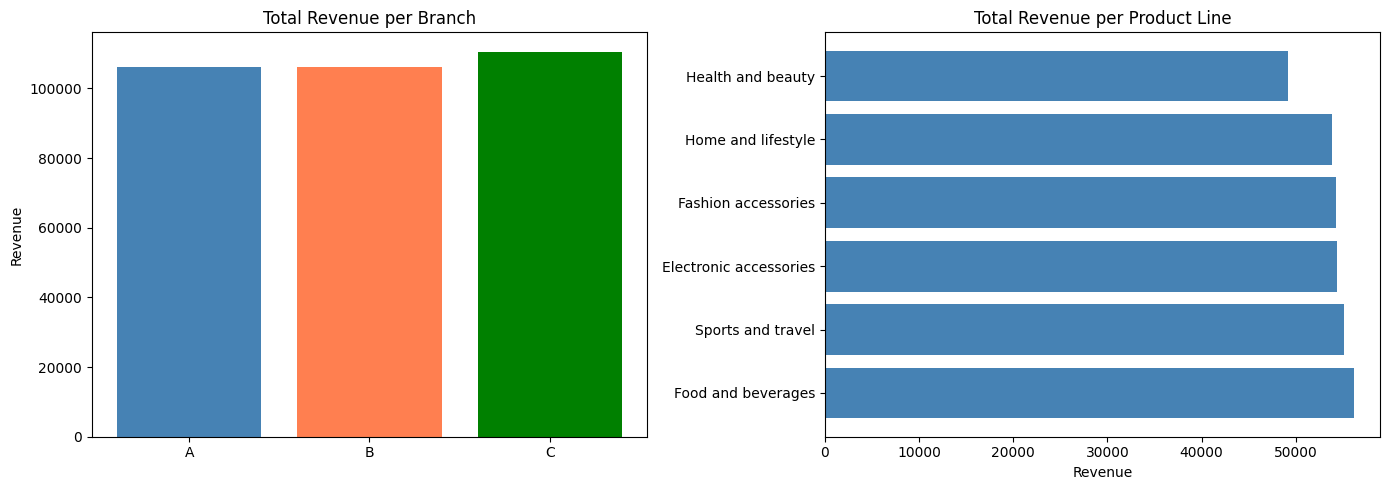

In [4]:
# Grouping per Branch
group_branch = df.groupby('Branch').agg(
    Total_Transaksi=('Invoice ID', 'count'),
    Rata_Rata_Total=('Total', 'mean'),
    Total_Revenue=('Total', 'sum'),
    Rata_Rata_Rating=('Rating', 'mean')
).round(2).reset_index()
print('Aggregasi per Branch:')
print(group_branch)

# Grouping per Product line
group_product = df.groupby('Product line').agg(
    Total_Transaksi=('Invoice ID', 'count'),
    Rata_Rata_Total=('Total', 'mean'),
    Total_Revenue=('Total', 'sum')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)
print('\nAggregasi per Product line:')
print(group_product)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(group_branch['Branch'], group_branch['Total_Revenue'], color=['steelblue','coral','green'])
axes[0].set_title('Total Revenue per Branch')
axes[0].set_ylabel('Revenue')
axes[1].barh(group_product['Product line'], group_product['Total_Revenue'], color='steelblue')
axes[1].set_title('Total Revenue per Product Line')
axes[1].set_xlabel('Revenue')
plt.tight_layout()
plt.show()

**Insight Grouping:**
Ketiga cabang (A, B, C) memiliki performa yang relatif seimbang. Dari sisi lini produk, Fashion accessories dan Food and beverages cenderung menghasilkan revenue tertinggi, sehingga bisa diprioritaskan dalam strategi stok dan promosi.

## d. Join / Merging
**Pertanyaan:** Informasi apa yang bisa kita dapatkan jika menggabungkan data penjualan dengan data cabang dan produk?

In [5]:
# Merge dengan branch_info
df_merged = pd.merge(df, df_branch, on='Branch', how='left')

# Merge dengan product_info
df_merged = pd.merge(df_merged, df_product, on='Product line', how='left')

print('Kolom setelah merge:', df_merged.columns.tolist())
print(f'Shape: {df_merged.shape}')
df_merged[['Invoice ID', 'Branch', 'Region', 'Manager', 'Product line', 'Category', 'Supplier', 'Total']].head(10)

Kolom setelah merge: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating', 'Region', 'Manager', 'Opened Year', 'Category', 'Supplier', 'Warranty (months)']
Shape: (1000, 23)


,Invoice ID,Branch,Region,Manager,Product line,Category,Supplier,Total
0,750-67-8428,A,South,Alice,Health and beauty,Beauty,Supplier A,548.9715
1,226-31-3081,C,North,Charlie,Electronic accessories,Electronics,Supplier B,80.2200
2,631-41-3108,A,South,Alice,Home and lifestyle,Home,Supplier C,340.5255
3,123-19-1176,A,South,Alice,Health and beauty,Beauty,Supplier A,489.0480
4,373-73-7910,A,South,Alice,Sports and travel,NaN,NaN,634.3785
5,699-14-3026,C,North,Charlie,Electronic accessories,Electronics,Supplier B,627.6165
6,355-53-5943,A,South,Alice,Electronic accessories,Electronics,Supplier B,433.6920
7,315-22-5665,C,North,Charlie,Home and lifestyle,Home,Supplier C,772.3800
8,665-32-9167,A,South,Alice,Health and beauty,Beauty,Supplier A,76.1460
9,692-92-5582,B,Central,Bob,Food and beverages,NaN,NaN,172.7460


**Insight Merging:**
Setelah digabungkan, kita bisa menganalisis performa penjualan berdasarkan Region, Manager, atau Supplier. Misalnya, kita dapat melihat region mana yang memiliki penjualan tertinggi atau supplier mana yang produknya paling laris.

## e. Pivot
**Pertanyaan:** Bagaimana perbandingan rata-rata total penjualan per cabang dan tipe pelanggan?

Pivot Table - Rata-rata Total per Branch & Customer Type:
Customer type  Member  Normal
Branch                       
A              321.18  303.83
B              325.48  314.33
C              336.58  337.66


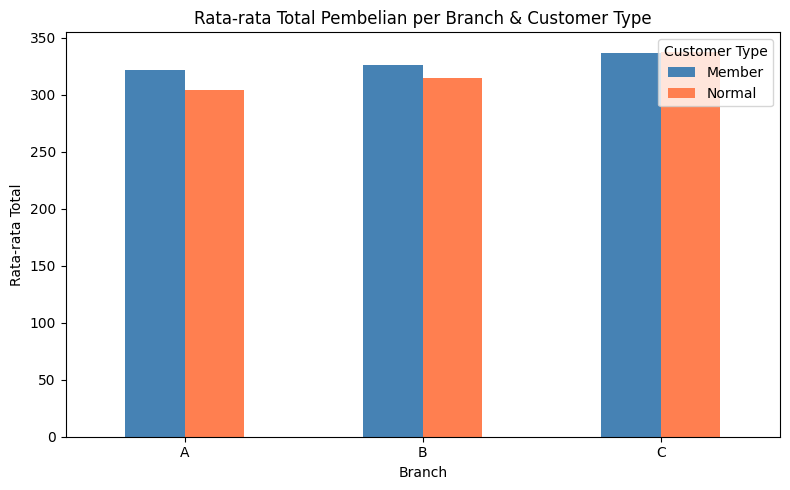

In [6]:
# Pivot table: rata-rata Total per Branch dan Customer type
pivot_table = df.pivot_table(
    values='Total',
    index='Branch',
    columns='Customer type',
    aggfunc='mean'
).round(2)
print('Pivot Table - Rata-rata Total per Branch & Customer Type:')
print(pivot_table)

# Visualisasi
pivot_table.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'coral'])
plt.title('Rata-rata Total Pembelian per Branch & Customer Type')
plt.ylabel('Rata-rata Total')
plt.xlabel('Branch')
plt.xticks(rotation=0)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

**Insight Pivot:**
Pivot table menunjukkan perbandingan nilai rata-rata transaksi antara Member dan Normal customer di setiap cabang. Jika rata-rata Member lebih tinggi, program keanggotaan terbukti mendorong pembelian lebih besar.

## f. Crosstab
**Pertanyaan:** Bagaimana distribusi frekuensi transaksi per cabang dan metode pembayaran?

Crosstab - Branch vs Payment Method:
Payment  Cash  Credit card  Ewallet  Total
Branch                                    
A         110          104      126    340
B         110          109      113    332
C         124           98      106    328
Total     344          311      345   1000

Proporsi (%) per Branch:
Payment  Cash  Credit card  Ewallet
Branch                             
A        32.4         30.6     37.1
B        33.1         32.8     34.0
C        37.8         29.9     32.3


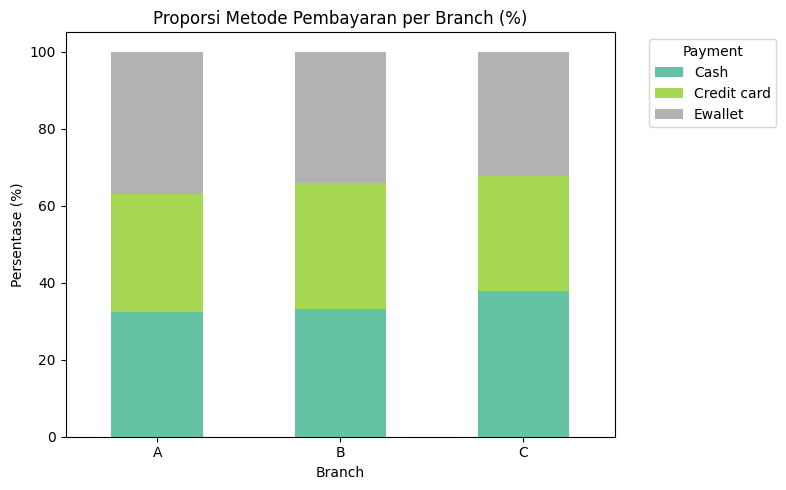

In [7]:
# Crosstab: Branch vs Payment
ct = pd.crosstab(df['Branch'], df['Payment'], margins=True, margins_name='Total')
print('Crosstab - Branch vs Payment Method:')
print(ct)

# Crosstab dalam bentuk proporsi (tanpa margins)
ct_pct = pd.crosstab(df['Branch'], df['Payment'], normalize='index').round(3) * 100
print('\nProporsi (%) per Branch:')
print(ct_pct)

# Visualisasi
ct_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Proporsi Metode Pembayaran per Branch (%)')
plt.ylabel('Persentase (%)')
plt.xlabel('Branch')
plt.xticks(rotation=0)
plt.legend(title='Payment', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Insight Crosstab:**
Distribusi metode pembayaran relatif merata di ketiga cabang. Informasi ini berguna untuk mempertimbangkan infrastruktur pembayaran yang perlu diperkuat di masing-masing cabang.

## g. Appending
**Pertanyaan:** Bagaimana cara menggabungkan data dari dua cabang berbeda menjadi satu dataset?

In [8]:
# Pisahkan data per branch
df_branch_A = df[df['Branch'] == 'A'].copy()
df_branch_B = df[df['Branch'] == 'B'].copy()
df_branch_C = df[df['Branch'] == 'C'].copy()

print(f'Jumlah data Branch A: {len(df_branch_A)}')
print(f'Jumlah data Branch B: {len(df_branch_B)}')
print(f'Jumlah data Branch C: {len(df_branch_C)}')

# Append: gabungkan Branch A dan Branch B
df_AB = pd.concat([df_branch_A, df_branch_B], ignore_index=True)
print(f'\nJumlah data setelah Append A+B: {len(df_AB)}')
print(df_AB['Branch'].value_counts())

# Append semua branch
df_all = pd.concat([df_branch_A, df_branch_B, df_branch_C], ignore_index=True)
print(f'\nJumlah data setelah Append semua: {len(df_all)}')

Jumlah data Branch A: 340
Jumlah data Branch B: 332
Jumlah data Branch C: 328

Jumlah data setelah Append A+B: 672
Branch
A    340
B    332
Name: count, dtype: int64

Jumlah data setelah Append semua: 1000


**Insight Appending:**
Appending sangat berguna ketika data dari beberapa sumber atau periode berbeda perlu digabungkan untuk analisis menyeluruh. `pd.concat` memastikan indeks di-reset sehingga tidak terjadi duplikasi indeks.

## h. Operasi Datetime
**Pertanyaan:** Apakah ada pola penjualan berdasarkan hari dalam seminggu atau jam tertentu?

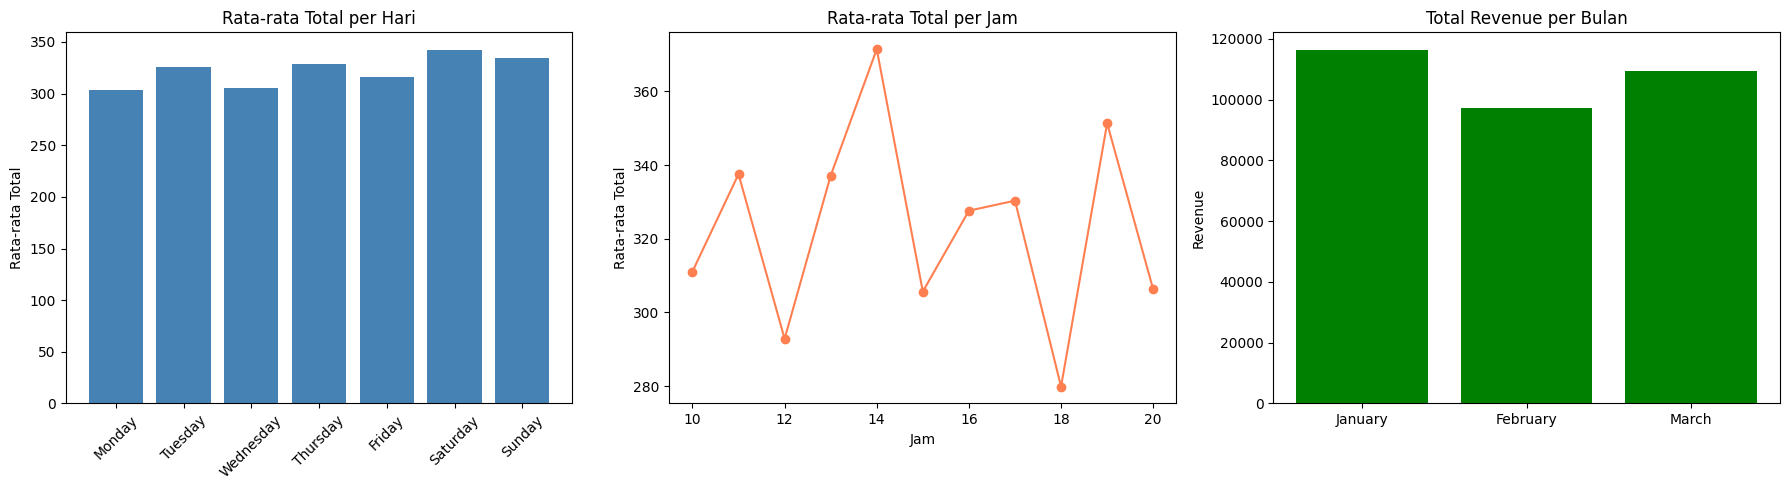

Penjualan per Hari:
DayOfWeek
Monday       303.19
Tuesday      325.84
Wednesday    305.81
Thursday     328.62
Friday       316.02
Saturday     342.20
Sunday       334.27
Name: Total, dtype: float64

Penjualan per Jam:
Hour
10    311.10
11    337.53
12    292.88
13    337.12
14    371.43
15    305.68
16    327.61
17    330.34
18    279.90
19    351.32
20    306.26
Name: Total, dtype: float64


In [9]:
# Ekstrak komponen datetime
df['DayOfWeek'] = df['Date'].dt.day_name()
df['DayNum'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month_name()
df['MonthNum'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Hour'] = df['Time'].dt.hour

# Penjualan per hari dalam seminggu
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales_by_day = df.groupby('DayOfWeek')['Total'].mean().reindex(day_order)

# Penjualan per jam
sales_by_hour = df.groupby('Hour')['Total'].mean().sort_index()

# Penjualan per bulan
month_order = ['January','February','March']
sales_by_month = df.groupby('Month')['Total'].sum().reindex(month_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(sales_by_day.index, sales_by_day.values, color='steelblue')
axes[0].set_title('Rata-rata Total per Hari')
axes[0].set_ylabel('Rata-rata Total')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(sales_by_hour.index, sales_by_hour.values, marker='o', color='coral')
axes[1].set_title('Rata-rata Total per Jam')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata Total')

axes[2].bar(sales_by_month.index, sales_by_month.values, color='green')
axes[2].set_title('Total Revenue per Bulan')
axes[2].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

print('Penjualan per Hari:')
print(sales_by_day.round(2))
print('\nPenjualan per Jam:')
print(sales_by_hour.round(2))

**Insight Datetime:**
Operasi datetime mengungkap pola waktu penjualan yang sangat berharga:
- Beberapa hari dalam seminggu mungkin memiliki penjualan lebih tinggi, misalnya Sabtu/Minggu.
- Jam sibuk (peak hours) dapat diidentifikasi untuk mengatur jadwal staf dan promosi flash sale.
- Tren bulanan membantu perencanaan stok dan anggaran promosi.

# 2. Standard Scaler for Exploratory Data Analysis
clue : lakukan tanpa splitting dataset ke train dan test
- lakukan pada kolom Total, Unit Price, dan tambahkan 2 kolom lainnya
- dan tulis insight dari yang anda dapat dari grafik tersebut

Statistik setelah Standard Scaling:
       Total_std  Unit price_std  Quantity_std  Rating_std
count   1000.000        1000.000      1000.000    1000.000
mean       0.000          -0.000         0.000       0.000
std        1.001           1.001         1.001       1.001
min       -1.271          -1.722        -1.543      -1.731
25%       -0.808          -0.861        -0.859      -0.857
50%       -0.281          -0.017        -0.175       0.016
75%        0.604           0.841         0.852       0.889
max        2.928           1.672         1.537       1.762


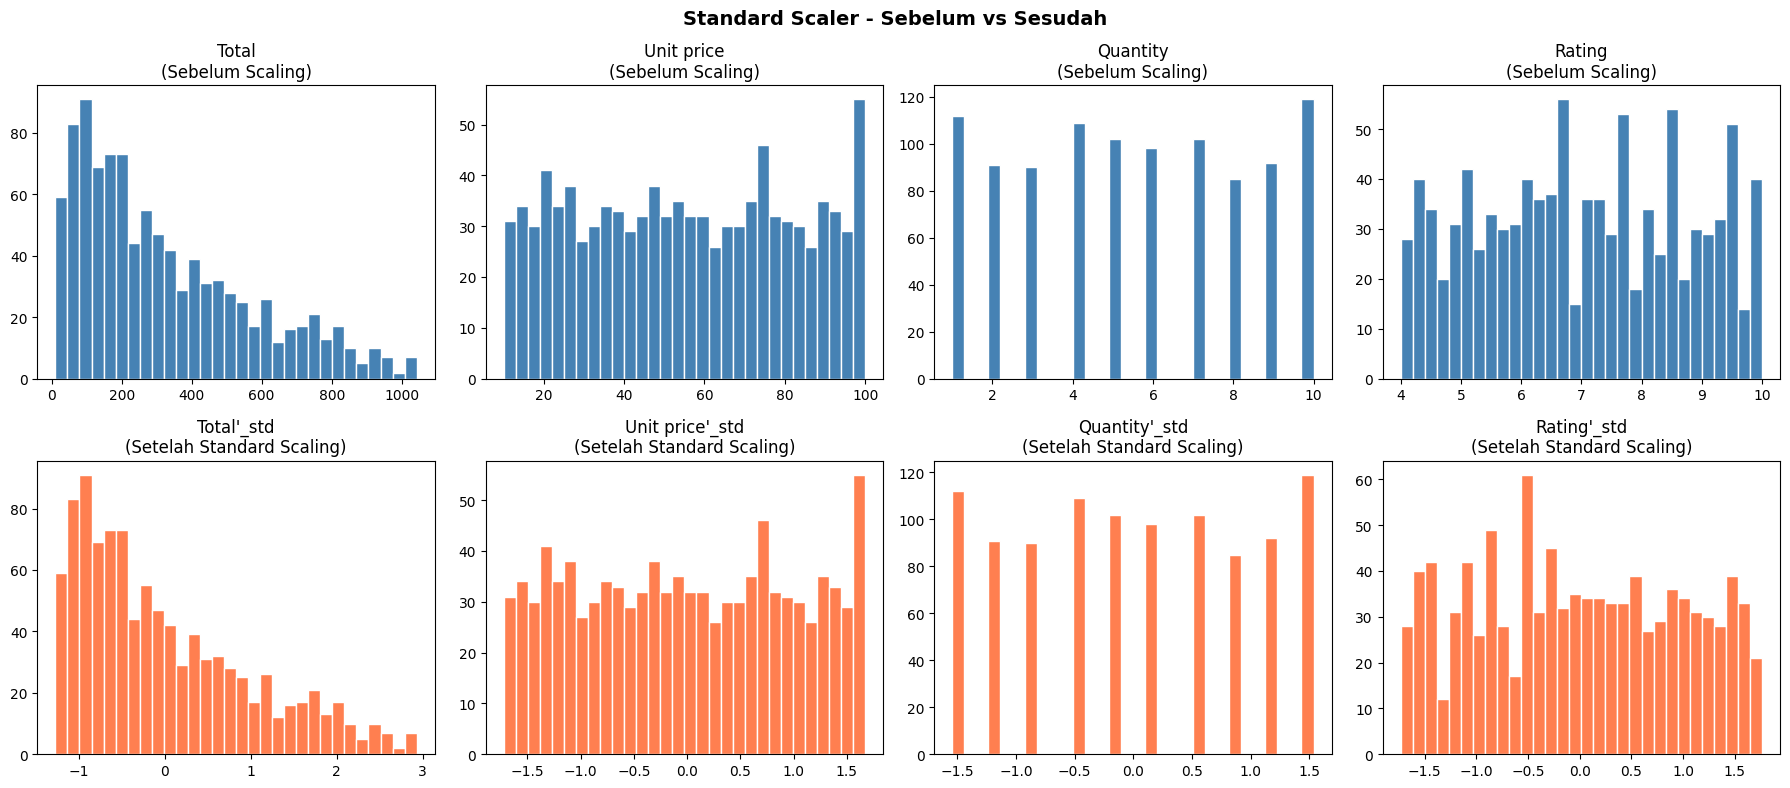

In [10]:
from sklearn.preprocessing import StandardScaler

# Kolom yang akan di-scale
cols_standard = ['Total', 'Unit price', 'Quantity', 'Rating']

scaler_std = StandardScaler()
df_standard = df[cols_standard].copy()
df_standard_scaled = pd.DataFrame(
    scaler_std.fit_transform(df_standard),
    columns=[col + '_std' for col in cols_standard]
)

print('Statistik setelah Standard Scaling:')
print(df_standard_scaled.describe().round(3))

# Visualisasi perbandingan sebelum dan sesudah
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cols_standard):
    # Sebelum scaling
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Sebelum Scaling)')
    # Sesudah scaling
    axes[1, i].hist(df_standard_scaled[col + '_std'], bins=30, color='coral', edgecolor='white')
    axes[1, i].set_title(f'{col}\'_std\n(Setelah Standard Scaling)')

plt.suptitle('Standard Scaler - Sebelum vs Sesudah', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight Standard Scaler:**
Standard Scaler (Z-score normalization) mengubah distribusi data sehingga memiliki mean = 0 dan standar deviasi = 1. Bentuk distribusi tidak berubah, namun skalanya diseragamkan.

- **Total & Unit Price**: Setelah scaling, nilai terpusat di sekitar 0 sehingga perbandingan antar kolom menjadi lebih adil.
- **Quantity**: Distribusinya relatif diskrit (1-10), setelah scaling tetap terlihat pola yang sama.
- **Rating**: Setelah scaling, terlihat distribusi rating yang cukup merata antara nilai rendah hingga tinggi.
Standard Scaler cocok untuk EDA ketika ingin membandingkan distribusi beberapa variabel dalam satu grafik tanpa bias skala.

# 3. MinMax Scaler for Exploratory Data Analysis
`clue` : lakukan tanpa splitting dataset ke train dan test
- lakukan pada kolom Total, Unit Price, dan tambahkan 2 kolom lainnya
- dan tulis insight dari yang anda dapat dari grafik tersebut

Statistik setelah MinMax Scaling:
       Total_minmax  Unit price_minmax  Quantity_minmax  Rating_minmax
count      1000.000           1000.000         1000.000       1000.000
mean          0.303              0.507            0.501          0.495
std           0.238              0.295            0.325          0.286
min           0.000              0.000            0.000          0.000
25%           0.110              0.254            0.222          0.250
50%           0.236              0.502            0.444          0.500
75%           0.446              0.755            0.778          0.750
max           1.000              1.000            1.000          1.000


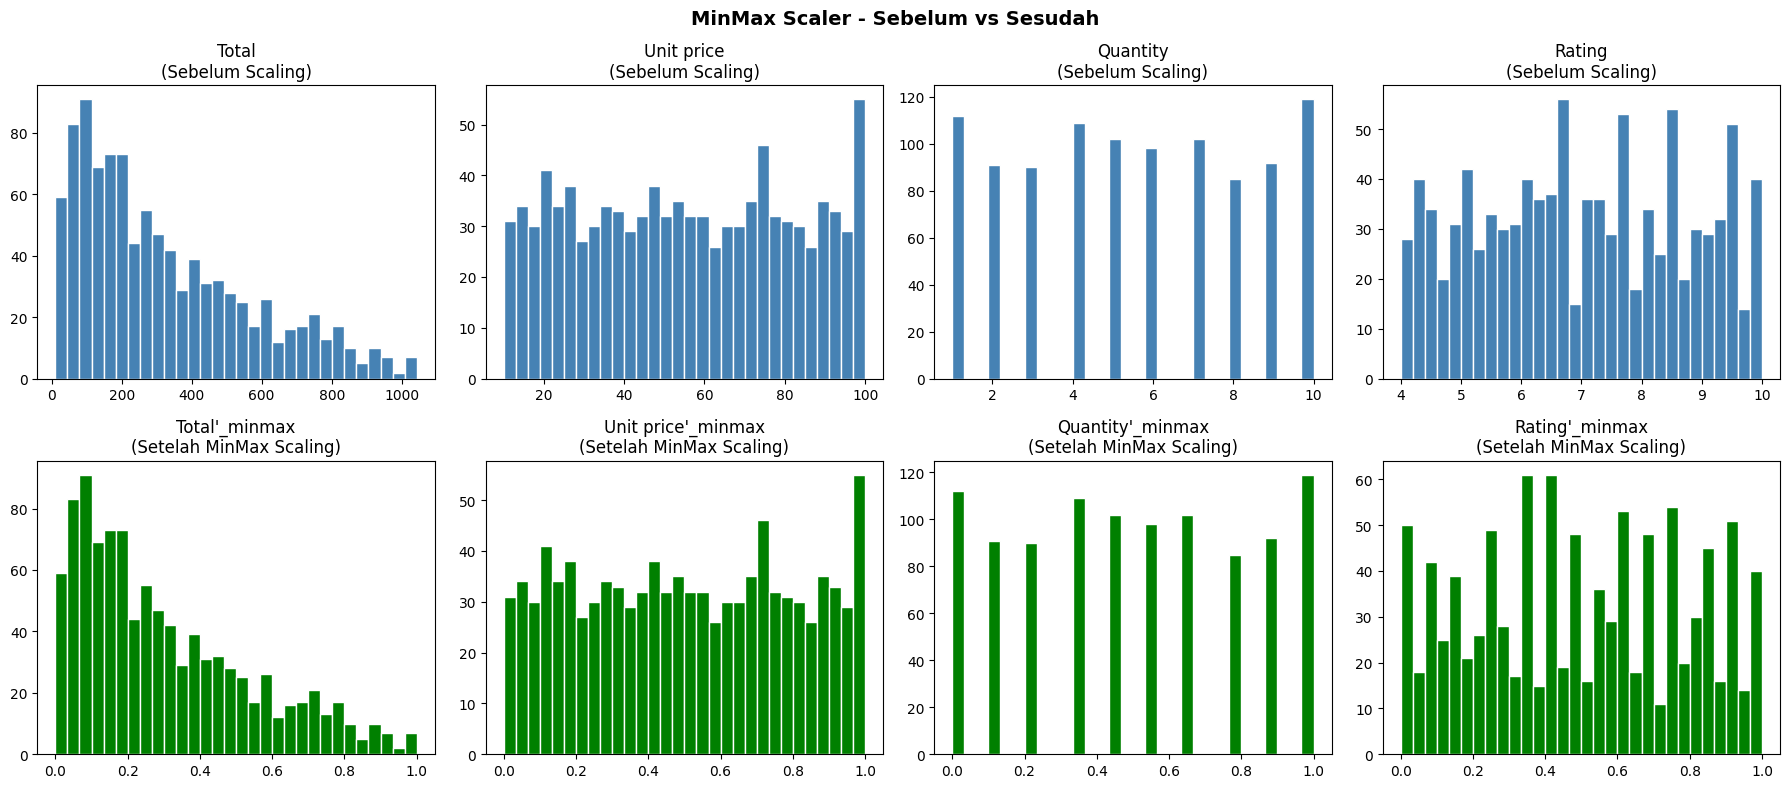

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Kolom yang akan di-scale (sama dengan Standard Scaler)
cols_minmax = ['Total', 'Unit price', 'Quantity', 'Rating']

scaler_mm = MinMaxScaler()
df_minmax = df[cols_minmax].copy()
df_minmax_scaled = pd.DataFrame(
    scaler_mm.fit_transform(df_minmax),
    columns=[col + '_minmax' for col in cols_minmax]
)

print('Statistik setelah MinMax Scaling:')
print(df_minmax_scaled.describe().round(3))

# Visualisasi perbandingan sebelum dan sesudah
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cols_minmax):
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Sebelum Scaling)')
    axes[1, i].hist(df_minmax_scaled[col + '_minmax'], bins=30, color='green', edgecolor='white')
    axes[1, i].set_title(f'{col}\'_minmax\n(Setelah MinMax Scaling)')

plt.suptitle('MinMax Scaler - Sebelum vs Sesudah', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight MinMax Scaler:**
MinMax Scaler mengubah nilai ke dalam rentang [0, 1] dengan mempertahankan bentuk distribusi asli.

- **Total**: Nilai terendah menjadi 0, nilai tertinggi menjadi 1. Bentuk distribusi tetap right-skewed.
- **Unit Price**: Setelah MinMax scaling, semua produk berada dalam skala yang sama (0-1).
- **Quantity**: Nilai 1 menjadi 0, nilai 10 menjadi 1. Distribusi diskrit tetap terlihat.
- **Rating**: MinMax scaling memudahkan perbandingan rating antar produk/cabang dalam skala seragam.

**Perbedaan Standard vs MinMax Scaler untuk EDA:**
MinMax Scaler lebih mudah diinterpretasikan (0 = minimum, 1 = maksimum), namun lebih sensitif terhadap outlier. Standard Scaler lebih robust terhadap outlier karena berbasis mean dan standar deviasi.